Dataset: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

In [1]:
# Mengimpor libraries umum yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Mengimpor libraries untuk pembuatan dan evaluasi model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.20.0


## Data Preparation

### Data Loading

In [3]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:19<00:00, 146MB/s]



In [4]:
!rm -rf /content/New\ Plant\ Diseases\ Dataset\(Augmented\)

In [7]:
import os
import shutil

# Direktori awal untuk train dan valid
source_train = "/content/new-plant-diseases-dataset/plant-diseases/train/"
source_valid = "/content/new-plant-diseases-dataset/plant-diseases/valid/"

# Direktori baru gabungan dataset potato
combined_dir = '/content/new-plant-diseases-dataset/dataset-potato'
os.makedirs(combined_dir, exist_ok=True)

# 3 kelas potato dari dataset
potato_classes = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

# Memindahkan dan menggabungkan data train dan valid ke satu folder
for cls in potato_classes:
    class_dir = os.path.join(combined_dir, cls)
    os.makedirs(class_dir, exist_ok=True)

    # Salin file dan folder dari train
    train_cls_dir = os.path.join(source_train, cls)
    if os.path.exists(train_cls_dir):
        for file in os.listdir(train_cls_dir):
            shutil.copy(os.path.join(train_cls_dir, file), os.path.join(class_dir, f"train_{file}"))

    # Salin file dan folder dari valid
    valid_cls_dir = os.path.join(source_valid, cls)
    if os.path.exists(valid_cls_dir):
        for file in os.listdir(valid_cls_dir):
            shutil.copy(os.path.join(valid_cls_dir, file), os.path.join(class_dir, f"valid_{file}"))

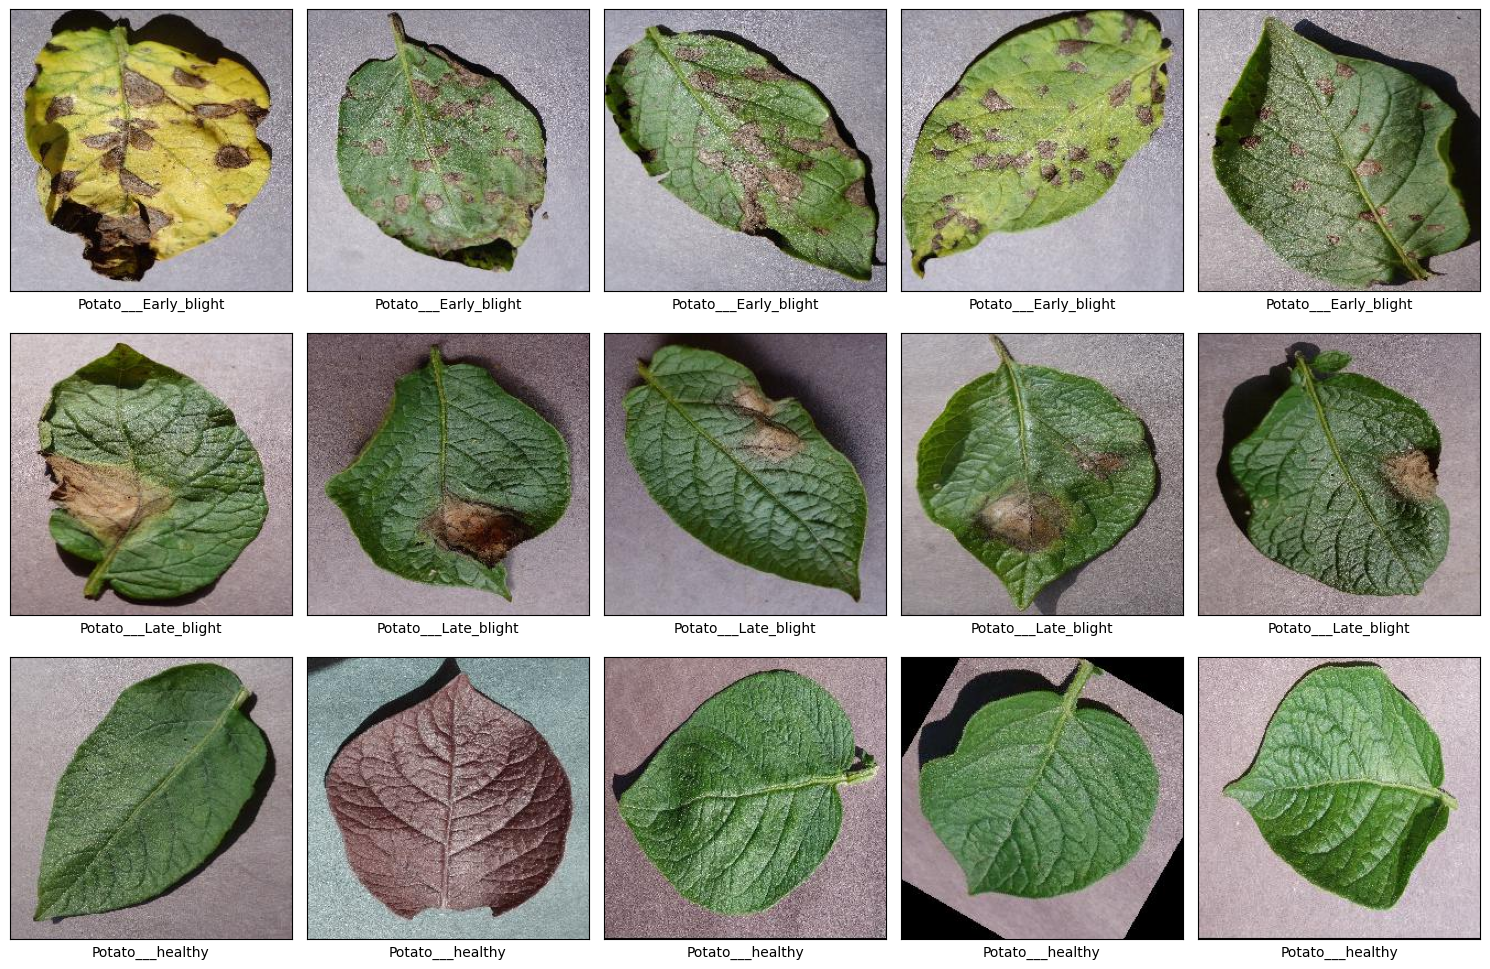

In [8]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
potato_image = {}

# Menentukan path sumber
path_sub = combined_dir
for cls_name in os.listdir(path_sub):
    potato_image[cls_name] = os.listdir(os.path.join(path_sub, cls_name))

# Menampilkan secara acak 5 gambar dari setiap kelas
fig, axs = plt.subplots(len(potato_image.keys()), 5, figsize=(15, 10))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(potato_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)

        img = Image.open(img_path)

        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()
plt.show()

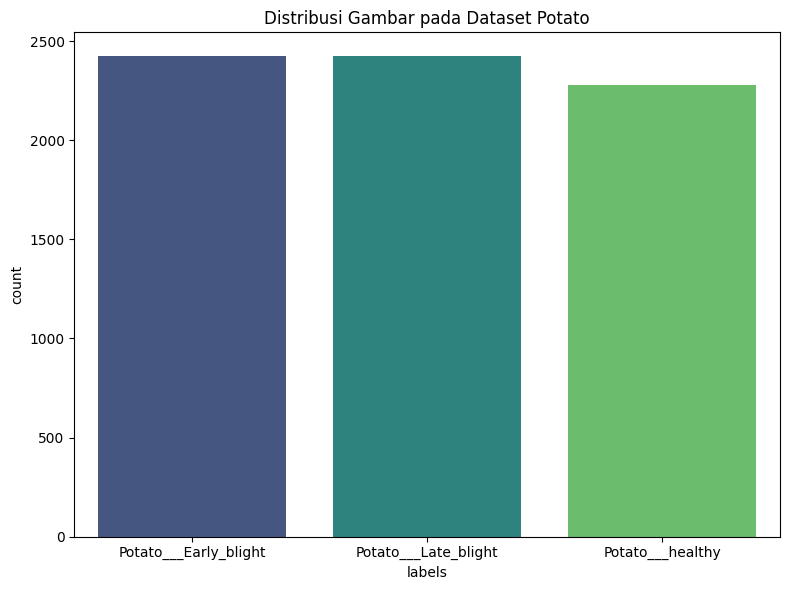

In [9]:
# Path sumber dataset potato
potato_path = "/content/new-plant-diseases-dataset/dataset-potato"

# List untuk menyimpan data nama file, path lengkap, dan label
file_name = []
labels = []
full_path = []

# Mengambil nama file, path lengkap, dan label gambar satu per satu menggunakan looping
for path, subdirs, files in os.walk(potato_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Menyimpan kumpulan data ke dalam Pandas DataFrame
distribution_potato = pd.DataFrame({
    "path": full_path,
    "file_name": file_name,
    "labels": labels
})

# Plot distribusi jumlah gambar di setiap kelas
plt.figure(figsize=(8, 6))
plot_data = sns.countplot(data=distribution_potato, x='labels', hue='labels', palette='viridis', legend=False)

plt.title("Distribusi Gambar pada Dataset Potato")
plt.tight_layout()
plt.show()

### Data Preprocessing

#### Split Dataset

In [24]:
# Library untuk membagi dataset menjadi 3 bagian (train, validation and test)
!pip install split-folders

In [12]:
import splitfolders

input_folder = "/content/new-plant-diseases-dataset/dataset-potato"
output_folder = "/content/Dataset-Final"

# Membagi dataset menjadi Train (80%), Validation (10%), dan Test (10%)
splitfolders.ratio(input_folder,
                   output=output_folder,
                   seed=42,
                   ratio=(0.8, 0.1, 0.1),
                   group_prefix=None)

Copying files: 7128 files [00:01, 4335.22 files/s]


#### Image Data Generator

In [13]:
# Path sumber dataset
TRAIN_DIR = "/content/Dataset-Final/train"
VAL_DIR = "/content/Dataset-Final/val"
TEST_DIR = "/content/Dataset-Final/test"

# Datagen untuk Train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Datagen untuk Validation & Test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Eksekusi Data Generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5702 images belonging to 3 classes.
Found 712 images belonging to 3 classes.
Found 714 images belonging to 3 classes.


## Modelling

In [15]:
# Membersihkan sesi sebelumnya
tf.keras.backend.clear_session()

# INIT SEQUENTIAL MODEL
model_1 = Sequential()

# Blok Konvolusi 1 (Perhatikan input_shape menjadi 3 channel warna RGB)
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D((2, 2)))

# Blok Konvolusi 2 (Menggunakan kernel 3x3 standar)
model_1.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D((2, 2)))

# Blok Konvolusi 3
model_1.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D((2, 2)))

# Flatten Layer (Meratakan matriks menjadi array 1D)
model_1.add(Flatten())

# Fully Connected Layer (Hidden Layer)
model_1.add(Dense(128, activation='relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(64, activation='relu'))
model_1.add(Dropout(0.3))

# Output Layer (3 Neuron untuk 3 Kelas, aktivasi Softmax)
model_1.add(Dense(3, activation='softmax'))

# COMPILE MODEL
model_1.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,411,139 (20.64 MB)

 Trainable params: 5,410,691 (20.64 MB)

 Non-trainable params: 448 (1.75 KB)

None


Epoch 1/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 54s 253ms/step - accuracy: 0.7866 - loss: 3.1259 - val_accuracy: 0.4312 - val_loss: 11.2280
Epoch 2/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 40s 221ms/step - accuracy: 0.8809 - loss: 0.8387 - val_accuracy: 0.3399 - val_loss: 13.1403
Epoch 3/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 39s 218ms/step - accuracy: 0.8995 - loss: 0.4950 - val_accuracy: 0.5056 - val_loss: 7.2868
Epoch 4/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 39s 218ms/step - accuracy: 0.9221 - loss: 0.3877 - val_accuracy: 0.8961 - val_loss: 0.2880
Epoch 5/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 39s 215ms/step - accuracy: 0.9330 - loss: 0.3572 - val_accuracy: 0.8469 - val_loss: 2.1583
Epoch 6/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 39s 218ms/step - accuracy: 0.9477 - loss: 0.2521 - val_accuracy: 0.6124 - val_loss: 8.3806
Epoch 7/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 39s 217ms/step - accuracy: 0.9509 - loss: 0.2336 - val_accuracy: 0.7612 - val_loss: 3.1370
Epoch 8/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.9598 - loss:

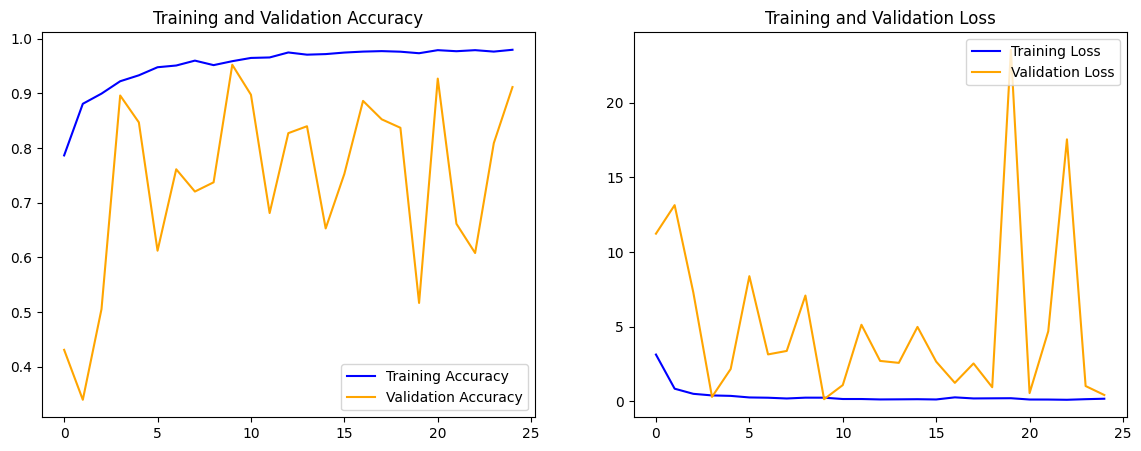

In [16]:
# TRAINING MODEL
# Menjalankan proses training tanpa class_weight karena data sudah balance
history_1 = model_1.fit(
    train_generator,
    epochs=25,
    batch_size=32,
    validation_data=validation_generator
)

# PLOT AKURASI & LOSS
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Evaluasi dan Visualisasi

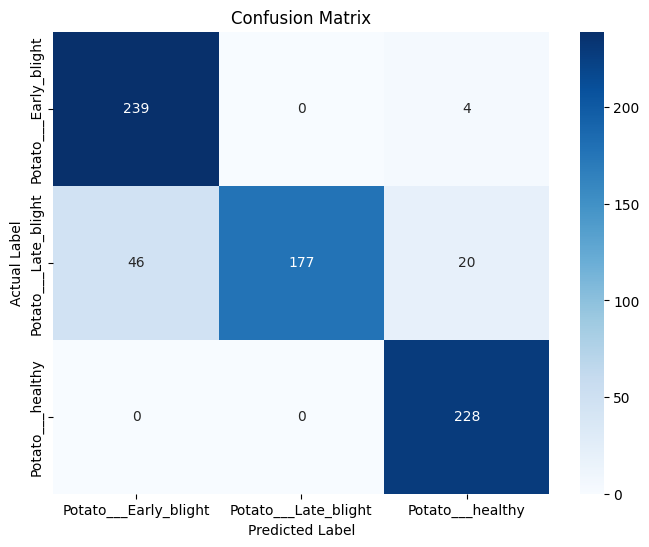


Classification Report:

                       precision    recall  f1-score   support

Potato___Early_blight     0.8386    0.9835    0.9053       243
 Potato___Late_blight     1.0000    0.7284    0.8429       243
     Potato___healthy     0.9048    1.0000    0.9500       228

             accuracy                         0.9020       714
            macro avg     0.9145    0.9040    0.8994       714
         weighted avg     0.9147    0.9020    0.8983       714



In [27]:
# EVALUASI (CONFUSION MATRIX & REPORT)
test_generator.reset()

# Melakukan prediksi pada data test
preds_raw = model_1.predict(test_generator, verbose=0)

# Mengambil indeks dengan probabilitas tertinggi menggunakan argmax
preds_classes = np.argmax(preds_raw, axis=1)

# Mengambil nama kelas asli dari generator
class_names = list(test_generator.class_indices.keys())

# Menampilkan Confusion Matrix
cm = confusion_matrix(test_generator.classes, preds_classes)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# Menampilkan Classification Report
print("\nClassification Report:\n")
print(classification_report(test_generator.classes, preds_classes, target_names=class_names, digits=4))

## Konversi Model

In [28]:
# Simpan dalam format SavedModel
print("Menyimpan format SavedModel")
model_1.export('saved_model/')

print("Format SavedModel berhasil disimpan")

Menyimpan format SavedModel
Saved artifact at 'saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132833545695888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545698960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545696464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545698000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545693584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545693776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545693392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545696080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545695312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545695120: TensorSpec(shape=(), dtype=tf.resource, nam

In [29]:
# Simpan dalam format TF-Lite
# Mengonversi model Keras menjadi TF-Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model_1)
tflite_model = converter.convert()

# Membuat folder dan menyimpan file .tflite
os.makedirs('tflite', exist_ok=True)
with open('tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Format TF-Lite berhasil disimpan")

Saved artifact at '/tmp/tmpz45dg3nf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132833545695888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545698960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545696464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545698000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545693584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545693776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545693392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545696080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545695312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132833545695120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13283354569320

In [30]:
# Membuat file label.txt
class_names = list(test_generator.class_indices.keys())
with open('tflite/label.txt', 'w') as f:
    f.write('\n'.join(class_names))

In [33]:
!pip install -q tensorflowjs

In [35]:
!tensorflowjs_converter --input_format=tf_saved_model saved_model/ tfjs_model/
print("Format TFJS berhasil disimpan")

2026-07-05 05:47:35.955988: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783230456.003789   38137 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783230456.016239   38137 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783230456.043479   38137 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783230456.043536   38137 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783230456.043547   38137 computation_placer.cc:177] computation placer alr

## Inference (Optional)